In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

In [7]:
#Create a MODEL Class that inherits nn.Module
class Model(nn.Module):
    #Input layer (4 features of flower) 
    #Hidden Layer (#neurons)  
    #H2 (#) 
    #Output(3 classes of flower)

    def __init__(self, in_features = 4, h1 = 8, h2 = 9, out_features = 3):

        super().__init__() #Instantiate our nn.Module
        
        self.fc1 = nn.Linear(in_features, h1) #fully connected, (starting, moving_forward)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    
    def forward(self, x):
        x = F.relu(self.fc1(x)) #Rectivied Linear Unit, of output is less than 0 call it 0
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x

In [8]:
#NN involve randomization, we need a seed

#Pick random seed for randomization
torch.manual_seed(66)

#Create insatnce of model
model = Model()

In [9]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [10]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [11]:
#CHange last col STR to FLOAT
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('versicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)
my_df

C:\Users\Sam\AppData\Local\Temp\ipykernel_23748\4253776456.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica', 2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [12]:
#Train Test Split! Set X, y
X = my_df.drop('species', axis=1)
y = my_df['species']

In [13]:
#Convert to numpy arrays
X = X.values
y = y.values

In [14]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [15]:
y

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 66)

In [18]:
#Convert X features to float tensor
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [19]:
#Convert y labels to tensor long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [20]:
#Set criterian of model to measure error, how far off predictions are from reality
criterion = nn.CrossEntropyLoss()

#Choose Adam Optimizer, lr = Learning Rate (if error doesnt go down after bunch of iterations(epochs), lower lr)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [21]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [22]:
#Train or model!

#Epochs? (1 run thru all trainig data)
epochs = 100
losses = []

for i in range(epochs):
    #Go forward and get a prediction
    y_predict = model.forward(X_train) #Get predicted results

    #Measure the loss/error, gonna be high at first
    loss = criterion(y_predict, y_train) #Predicted values vs the y_train

    #Keep Track of our losses
    losses.append(loss.detach().numpy())

    #Print every 10 epochs
    if i % 10 == 0:
        print(f"Epoch: {i} and loss: {loss}")
    #Do some back propagation: take the error rate of forward propagation and feed it back thru the network to fine tune the weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 and loss: 1.1740525960922241
Epoch: 10 and loss: 0.989161491394043
Epoch: 20 and loss: 0.7703238725662231
Epoch: 30 and loss: 0.5191901326179504
Epoch: 40 and loss: 0.37349507212638855
Epoch: 50 and loss: 0.23888924717903137
Epoch: 60 and loss: 0.13773444294929504
Epoch: 70 and loss: 0.08969717472791672
Epoch: 80 and loss: 0.07081369310617447
Epoch: 90 and loss: 0.06259267777204514


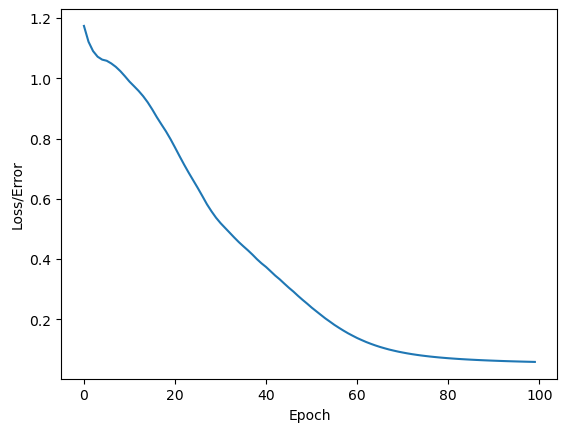

In [23]:
#Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("Loss/Error")
plt.xlabel("Epoch")
plt.show()

In [24]:
#Evaluate Moodel on Test Data Set (validate model on test set)
with torch.no_grad() : #Bascally turn off the back propagation
    y_eval = model.forward(X_test) #X_test are features from our test set, y_eval will be predictions
    loss = criterion(y_eval, y_test) #Find the loss/error

In [25]:
loss

tensor(0.0975)

In [26]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        if y_test[i] == 0:
            x = 'setosa'
        elif y_test[i] == 1:
            x = 'versicolor'
        else:
            x = 'virginica'

        #Will tell us what type of flower class our network thinks it is
        print(f'{i+1}.) {str(y_val)}  \t {y_test[i]} \t{y_val.argmax().item()}')

        #Correct or not
        if y_val.argmax().item() == y_test[i]:
            correct += 1
print (f'We got {correct} correct!')

1.) tensor([-2.7878,  4.5250, -1.4885])  	 1 	1
2.) tensor([-4.4145,  4.7272,  0.4923])  	 1 	1
3.) tensor([-4.4074,  4.5265,  0.6970])  	 1 	1
4.) tensor([  6.5908,   0.3712, -11.7378])  	 0 	0
5.) tensor([-3.3257,  4.8213, -1.1129])  	 1 	1
6.) tensor([-2.3960,  4.2852, -1.7356])  	 1 	1
7.) tensor([  6.2632,   0.3174, -11.0081])  	 0 	0
8.) tensor([  7.0512,   0.2816, -12.4717])  	 0 	0
9.) tensor([ 5.5570,  0.3659, -9.7361])  	 0 	0
10.) tensor([-7.8112,  4.2049,  5.3830])  	 2 	2
11.) tensor([-8.2662,  3.6257,  6.5837])  	 2 	2
12.) tensor([-8.0384,  3.8876,  5.9914])  	 2 	2
13.) tensor([  6.0451,   0.3273, -10.6030])  	 0 	0
14.) tensor([-6.3007,  3.8103,  3.8749])  	 2 	2
15.) tensor([-8.7604,  2.8779,  8.0251])  	 2 	2
16.) tensor([ 5.3805,  0.3802, -9.4088])  	 0 	0
17.) tensor([-2.2944,  3.9960, -1.4515])  	 1 	1
18.) tensor([-6.4853,  3.7087,  4.2392])  	 1 	2
19.) tensor([-10.5214,   3.4923,   9.6086])  	 2 	2
20.) tensor([-12.1549,   3.2690,  11.9236])  	 2 	2
21.) tensor

In [27]:
new_iris = torch.tensor([4.7, 3.2, 1.2, 0.2])

In [28]:
with torch.no_grad():
    print (model(new_iris))

tensor([  5.8726,   0.3359, -10.2844])


In [32]:
newer_iris = torch.tensor([5.9, 3.0, 5.1, 1.8])

In [33]:
with torch.no_grad():
    print(model(newer_iris))

tensor([-7.4885,  3.4536,  5.7769])


In [34]:
#Save and Load NN Model
torch.save(model.state_dict(), "Iris_Model_NN.pt") #Save it as a dictionary

In [35]:
#Load the Saved Model
new_model = Model()
new_model.load_state_dict(torch.load("Iris_Model_NN.pt"))

<All keys matched successfully>

In [36]:
#Make sure it loaded correctly
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)